# Convert Fazzari et al. (2024) to h5ad

In [1]:
import os
import scanpy as sc
import pandas as pd
import scipy

In [2]:
data_folder = "data"

In [3]:
sc.set_figure_params(frameon=False)
sc.settings.verbosity = 3

## Dataset import

import count matrix and convert it to sparse format

In [4]:
adata = sc.read_text(os.path.join(data_folder, "fazzari_2024", "exprMatrix.tsv.gz"), delimiter="\t", first_column_names=True).T
sparse_X = scipy.sparse.csr_matrix(adata.X)
adata.X = sparse_X
adata.obs.index = adata.obs.index.str.replace("2985_2p", "2985_2")

import cell annotation and store it in the adata

In [5]:
meta = pd.read_csv(os.path.join(data_folder, "fazzari_2024", "meta.tsv"), sep="\t", index_col=0)
adata.obs = meta

import original dimensionality reduction (UMAP) and store it in the adata

In [6]:
df = pd.read_csv(os.path.join(data_folder, "fazzari_2024", "UMAP.coords.tsv.gz"), sep="\t", header=None, index_col=0)
adata.obsm['X_umap'] = df.to_numpy()

In [7]:
adata.var.index = adata.var.index.map(lambda x: x.split("|")[0])

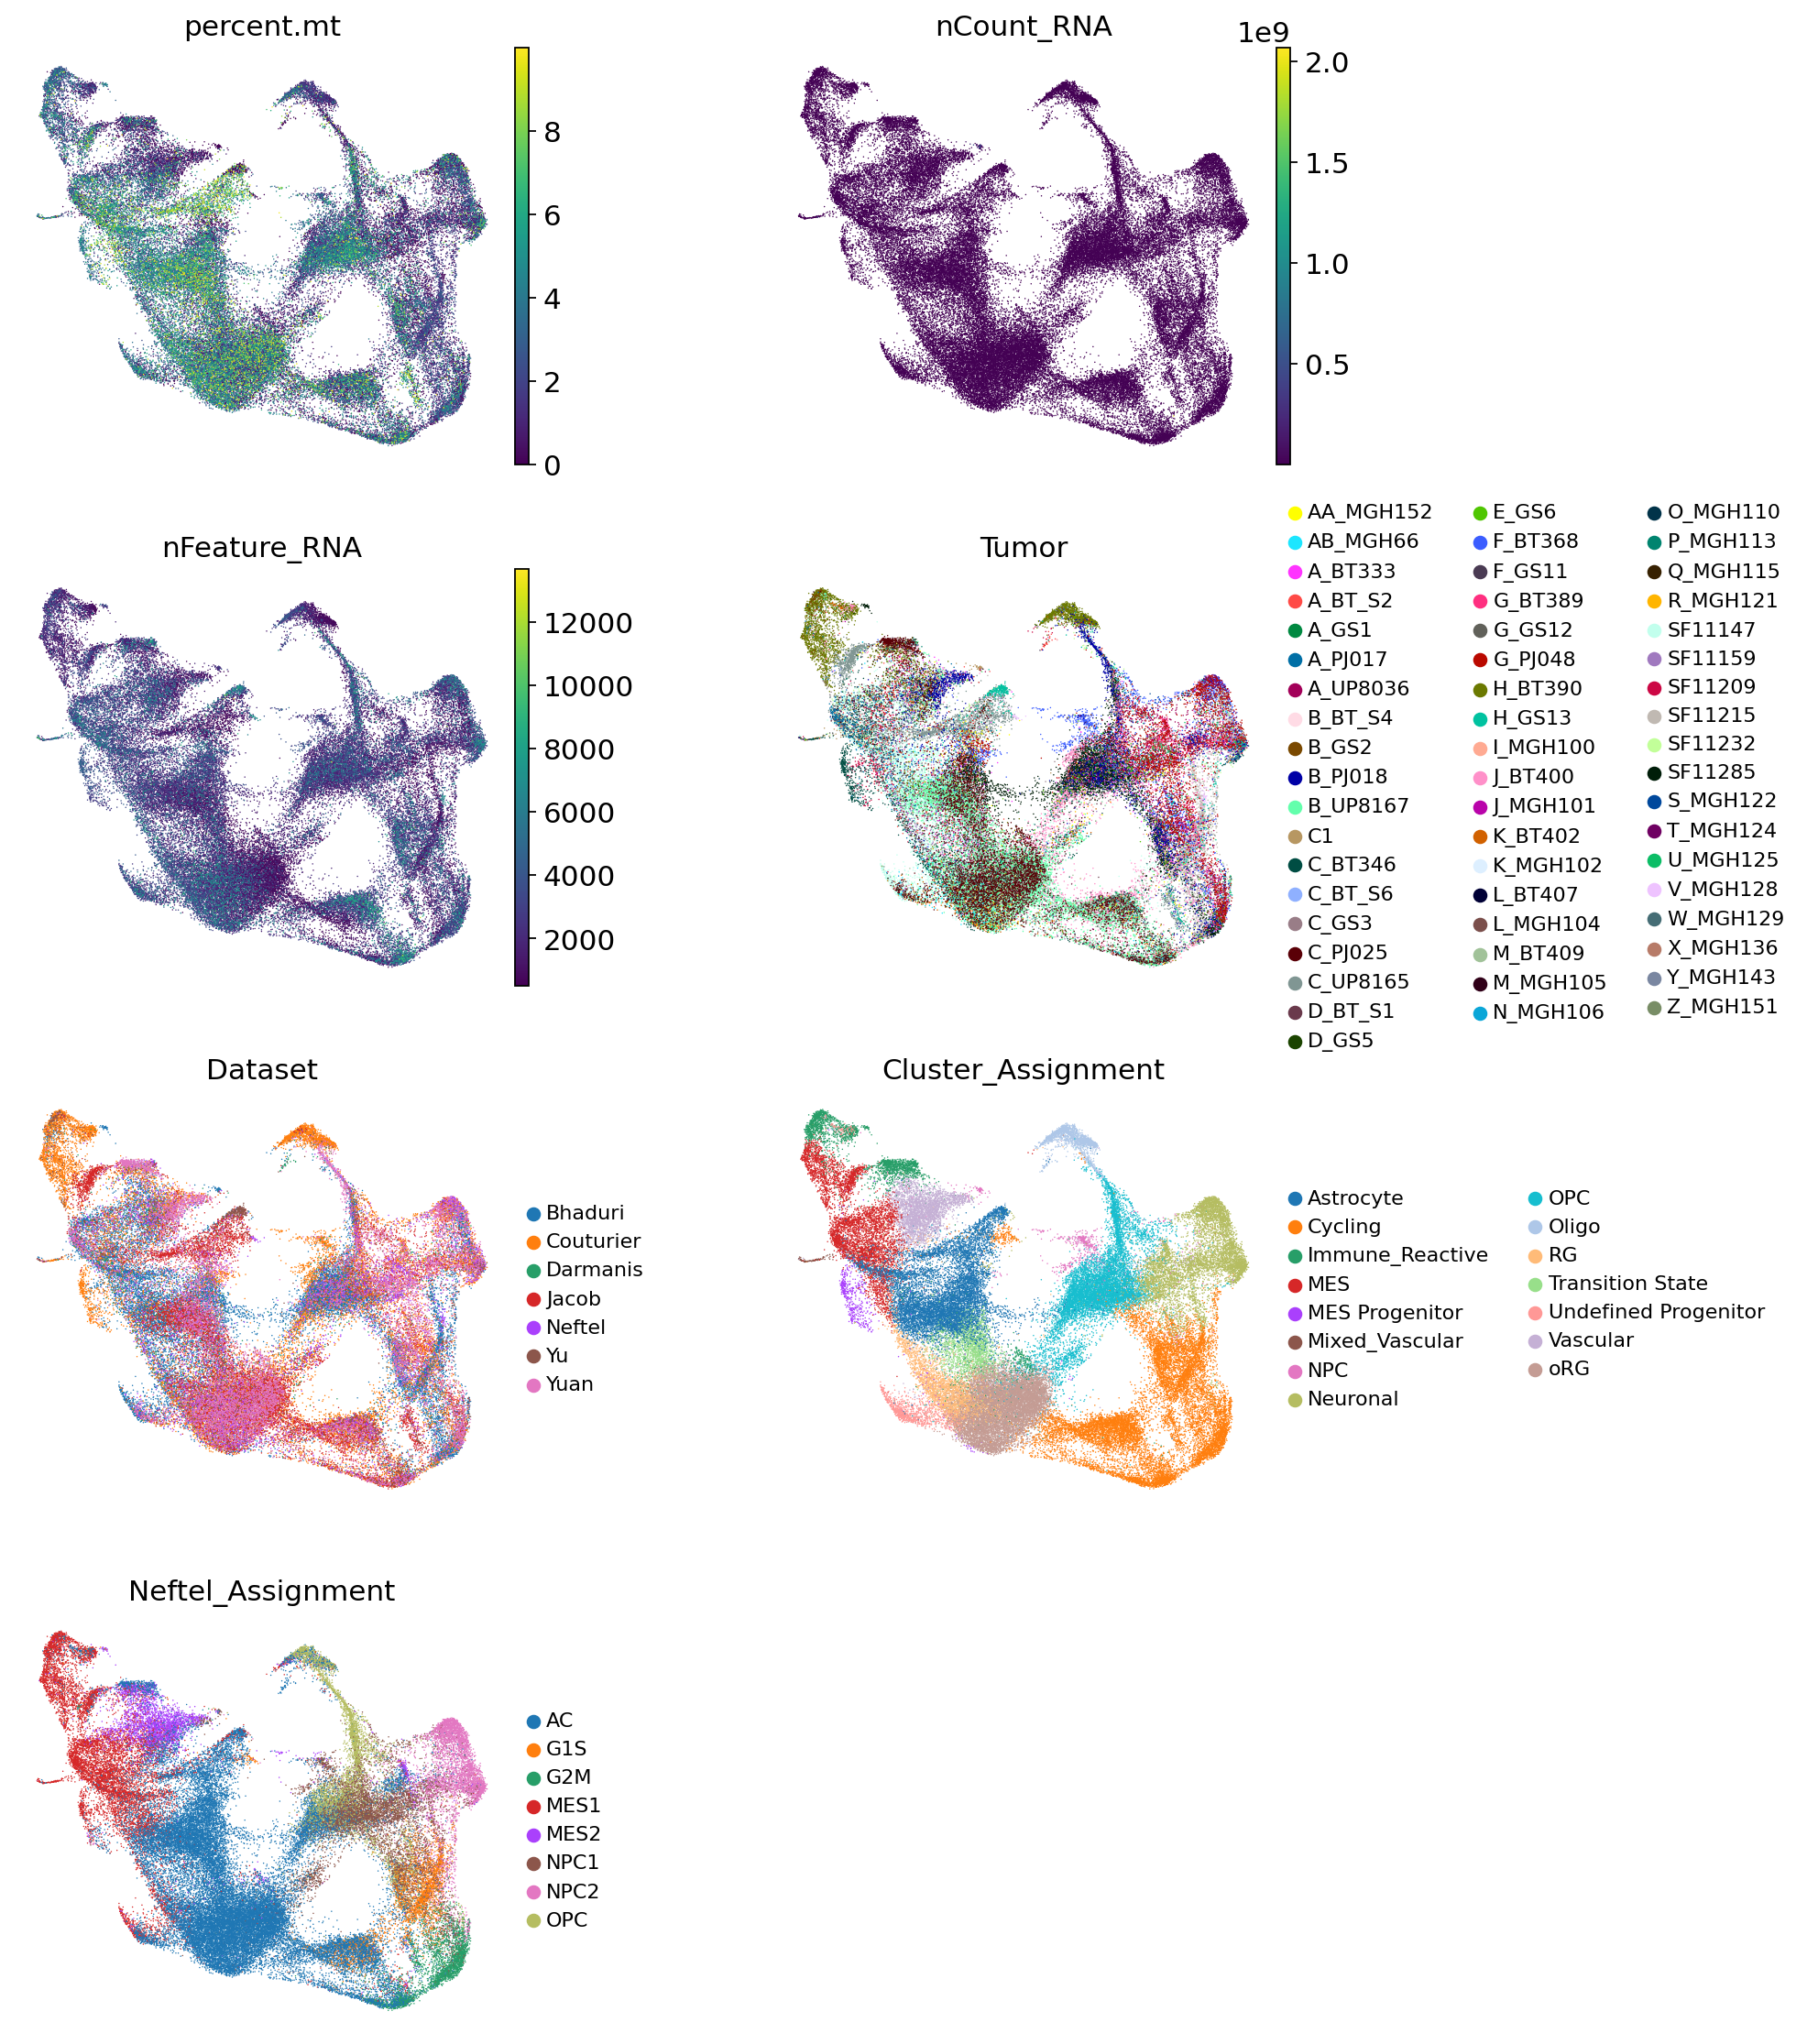

In [8]:
sc.pl.umap(adata, color=['percent.mt', 'nCount_RNA', 'nFeature_RNA', 
                           'Tumor', 'Dataset', 'Cluster_Assignment', 
                           'Neftel_Assignment',], 
           ncols=2, wspace=0.4, legend_fontsize=10)

## Save dataset in h5ad

In [9]:
adata

AnnData object with n_obs × n_vars = 69547 × 45438
    obs: 'percent.mt', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Tumor', 'Dataset', 'Cluster_Assignment', 'Neftel_Assignment', 'Integrated_ID'
    uns: 'Tumor_colors', 'Dataset_colors', 'Cluster_Assignment_colors', 'Neftel_Assignment_colors'
    obsm: 'X_umap'

In [10]:
adata.write(filename=os.path.join(data_folder, "fazzari_2024.h5ad"))